# AI-Driven Natural Language Processing Project
## Exploring BERT for Sentiment Analysis

**Task 3 - Advanced Level**

**Language Model Selected:** BERT (`bert-base-uncased`)

**Author:** Meghana Yara | B.Tech CSE (AI/ML), PVPSIT

---


## Cell 1 - Environment Setup

Install the libraries required for this project.

In [1]:
!pip install -q transformers datasets torch scikit-learn matplotlib seaborn

import transformers, torch, sklearn
print("transformers:", transformers.__version__)
print("torch       :", torch.__version__)
print("sklearn     :", sklearn.__version__)
print("GPU available:", torch.cuda.is_available())


[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip
C:\Users\yaram_pgsjsj8\AppData\Local\Programs\Python\Python314\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


transformers: 5.16.1
torch       : 2.13.0+cpu
sklearn     : 1.9.0
GPU available: False


## Cell 2 - Introduction and Research Questions

### What is BERT?

**BERT** (Bidirectional Encoder Representations from Transformers) was introduced by Google
in 2018. Its defining innovation is **bidirectionality**: unlike earlier models that read text
strictly left-to-right, BERT reads the entire sentence at once, so every word is understood in
the context of the words both before *and* after it.

BERT is pre-trained on two self-supervised objectives:

| Objective | What it does |
|---|---|
| **Masked Language Modeling (MLM)** | Randomly hides 15% of words and trains the model to predict them from surrounding context |
| **Next Sentence Prediction (NSP)** | Trains the model to judge whether one sentence logically follows another |

### Key architecture details (`bert-base-uncased`)

- 12 transformer encoder layers
- 768 hidden dimensions
- 12 self-attention heads
- ~110 million parameters
- Maximum input length: **512 tokens**
- "uncased" means text is lowercased and accents are stripped before tokenization

### Important distinction: base model vs. fine-tuned model

`bert-base-uncased` on its own is a **general-purpose language understanding model**. It has
*no* sentiment capability out of the box - attaching a classification head to it produces
randomly initialized weights and therefore meaningless predictions.

This notebook therefore demonstrates **both**:

1. The **base model** (`bert-base-uncased`) performing masked-word prediction - showing its raw
   contextual understanding.
2. A **fine-tuned variant** (`textattack/bert-base-uncased-SST-2`) performing sentiment
   classification - the same BERT architecture, adapted to a downstream task.

This contrast is itself one of the most instructive findings of the project.

---

### Research Questions

1. **RQ1** - How accurately does fine-tuned BERT classify sentiment on unseen movie reviews?
2. **RQ2** - Does BERT genuinely use bidirectional context, or does it rely on isolated
   sentiment-carrying keywords?
3. **RQ3** - How does BERT handle **negation** (e.g. "not good") and **sarcasm**, where surface
   wording contradicts intended meaning?
4. **RQ4** - What is the practical impact of the 512-token input limit on long documents?
5. **RQ5** - What **social biases** are detectable in the model's outputs, and what are the
   ethical implications of deploying it?

---

## Cell 3 - Load the Tokenizer and the IMDB Dataset

The tokenizer converts raw text into the subword token IDs BERT expects. We also load the
IMDB movie review dataset (50,000 labelled reviews, balanced between positive and negative).

In [2]:
from transformers import AutoTokenizer
from datasets import load_dataset

# --- Load tokenizer ---
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

print("Vocabulary size :", tokenizer.vocab_size)
print("Max length      :", tokenizer.model_max_length)
print("Special tokens  :", tokenizer.all_special_tokens)

Vocabulary size : 30522
Max length      : 512
Special tokens  : ['[UNK]', '[SEP]', '[PAD]', '[CLS]', '[MASK]']


In [3]:
# --- Inspect how BERT tokenizes text (WordPiece subword tokenization) ---
sample = "BERT uses bidirectional transformers for unbelievably good NLP."

tokens = tokenizer.tokenize(sample)
ids = tokenizer.convert_tokens_to_ids(tokens)

print("Original :", sample)
print("Tokens   :", tokens)
print("IDs      :", ids)
print()
print("Note the '##' prefixes - these mark subword continuations.")
print("Rare words are split into known pieces instead of becoming [UNK].")

Original : BERT uses bidirectional transformers for unbelievably good NLP.
Tokens   : ['bert', 'uses', 'bid', '##ire', '##ction', '##al', 'transformers', 'for', 'un', '##bel', '##ie', '##va', '##bly', 'good', 'nl', '##p', '.']
IDs      : [14324, 3594, 7226, 7442, 7542, 2389, 19081, 2005, 4895, 8671, 2666, 3567, 6321, 2204, 17953, 2361, 1012]

Note the '##' prefixes - these mark subword continuations.
Rare words are split into known pieces instead of becoming [UNK].


In [5]:
# --- Load the IMDB dataset ---
dataset = load_dataset("stanfordnlp/imdb")

print(dataset)
print()
print("Label meaning: 0 = negative, 1 = positive")
print()
print("--- Example review (truncated) ---")
print(dataset["test"][0]["text"][:400], "...")
print()
print("Label:", dataset["test"][0]["label"])

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    unsupervised: Dataset({
        features: ['text', 'label'],
        num_rows: 50000
    })
})

Label meaning: 0 = negative, 1 = positive

--- Example review (truncated) ---
I love sci-fi and am willing to put up with a lot. Sci-fi movies/TV are usually underfunded, under-appreciated and misunderstood. I tried to like this, I really did, but it is to good TV sci-fi as Babylon 5 is to Star Trek (the original). Silly prosthetics, cheap cardboard sets, stilted dialogues, CG that doesn't match the background, and painfully one-dimensional characters cannot be overcome wit ...

Label: 0


## Cell 4 - Load BERT and Run Sentiment Predictions

### 4a. The base model: masked-word prediction

First we show what `bert-base-uncased` can do *without* any fine-tuning. This demonstrates
its bidirectional contextual understanding directly.

In [6]:
from transformers import pipeline

fill_mask = pipeline("fill-mask", model="bert-base-uncased")

examples = [
    "The movie was absolutely [MASK].",
    "She went to the [MASK] to buy some milk.",
    "Paris is the [MASK] of France.",
]

for text in examples:
    print(f"Input: {text}")
    for pred in fill_mask(text)[:3]:
        print(f"   -> {pred['token_str']:<15} (score: {pred['score']:.4f})")
    print()

Loading weights: 100%|██████████| 202/202 [00:00<00:00, 1290.82it/s]
[transformers] BertForMaskedLM LOAD REPORT from: bert-base-uncased
Key                         | Status     |  | 
----------------------------+------------+--+-
cls.seq_relationship.weight | UNEXPECTED |  | 
bert.pooler.dense.weight    | UNEXPECTED |  | 
bert.pooler.dense.bias      | UNEXPECTED |  | 
cls.seq_relationship.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Input: The movie was absolutely [MASK].
   -> fantastic       (score: 0.0932)
   -> perfect         (score: 0.0604)
   -> beautiful       (score: 0.0577)

Input: She went to the [MASK] to buy some milk.
   -> store           (score: 0.3587)
   -> fridge          (score: 0.1782)
   -> kitchen         (score: 0.1170)

Input: Paris is the [MASK] of France.
   -> capital         (score: 0.9969)
   -> heart           (score: 0.0006)
   -> center          (score: 0.0004)



### 4b. The fine-tuned model: sentiment classification

Now we load the same BERT architecture, fine-tuned on SST-2 (Stanford Sentiment Treebank),
and use it for actual sentiment prediction.

In [7]:
from transformers import AutoModelForSequenceClassification
import torch

MODEL_NAME = "textattack/bert-base-uncased-SST-2"

sentiment_tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
sentiment_model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME)
sentiment_model.eval()

print("Model loaded:", MODEL_NAME)
print("Number of parameters:", f"{sentiment_model.num_parameters():,}")
print("Number of output labels:", sentiment_model.config.num_labels)

Loading weights: 100%|██████████| 201/201 [00:00<00:00, 7595.91it/s]

Model loaded: textattack/bert-base-uncased-SST-2
Number of parameters: 109,483,778
Number of output labels: 2


In [8]:
def predict_sentiment(texts):
    """Return (label, confidence) for each input text."""
    if isinstance(texts, str):
        texts = [texts]

    inputs = sentiment_tokenizer(
        texts, return_tensors="pt",
        truncation=True, padding=True, max_length=512
    )

    with torch.no_grad():
        logits = sentiment_model(**inputs).logits

    probs = torch.softmax(logits, dim=-1)
    results = []
    for p in probs:
        idx = int(torch.argmax(p))
        label = "POSITIVE" if idx == 1 else "NEGATIVE"
        results.append((label, float(p[idx])))
    return results


# --- Quick sanity check ---
test_sentences = [
    "This film was an absolute masterpiece from start to finish.",
    "I have never been so bored in my entire life.",
    "The acting was fine but the plot dragged on forever.",
]

for sent, (label, conf) in zip(test_sentences, predict_sentiment(test_sentences)):
    print(f"{label:<9} ({conf:.3f})  |  {sent}")

POSITIVE  (1.000)  |  This film was an absolute masterpiece from start to finish.
NEGATIVE  (0.996)  |  I have never been so bored in my entire life.
NEGATIVE  (0.998)  |  The acting was fine but the plot dragged on forever.


### 4c. RQ1 - Quantitative evaluation on IMDB

We evaluate on a random sample of the IMDB test set and report accuracy, precision, recall,
F1, and a confusion matrix.

In [9]:
from sklearn.metrics import (accuracy_score, precision_recall_fscore_support,
                             classification_report, confusion_matrix)
import numpy as np

# Sample 300 reviews for a manageable but meaningful evaluation
SAMPLE_SIZE = 300
sampled = dataset["test"].shuffle(seed=42).select(range(SAMPLE_SIZE))

texts = sampled["text"]
true_labels = sampled["label"]

# Predict in batches to avoid memory issues
pred_labels = []
BATCH = 16
for i in range(0, len(texts), BATCH):
    batch = texts[i:i+BATCH]
    preds = predict_sentiment(batch)
    pred_labels.extend([1 if lbl == "POSITIVE" else 0 for lbl, _ in preds])
    print(f"Processed {min(i+BATCH, len(texts))}/{len(texts)}", end="\r")

print("\nDone.")

Processed 300/300
Done.


In [10]:
acc = accuracy_score(true_labels, pred_labels)
prec, rec, f1, _ = precision_recall_fscore_support(true_labels, pred_labels, average="binary")

print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1 Score : {f1:.4f}")
print()
print(classification_report(true_labels, pred_labels,
                            target_names=["Negative", "Positive"]))

Accuracy : 0.8867
Precision: 0.8867
Recall   : 0.8867
F1 Score : 0.8867

              precision    recall  f1-score   support

    Negative       0.89      0.89      0.89       150
    Positive       0.89      0.89      0.89       150

    accuracy                           0.89       300
   macro avg       0.89      0.89      0.89       300
weighted avg       0.89      0.89      0.89       300



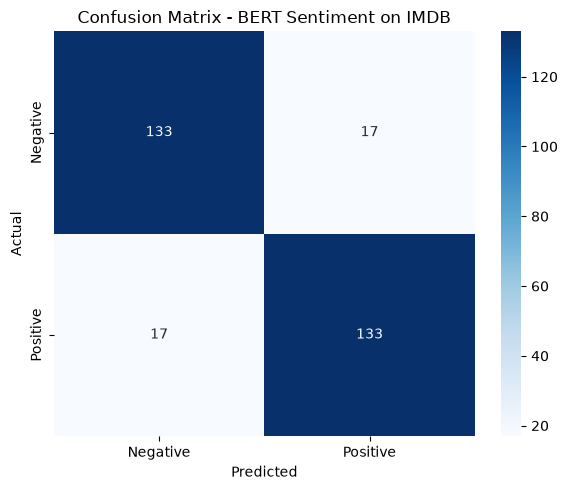

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(true_labels, pred_labels)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Negative", "Positive"],
            yticklabels=["Negative", "Positive"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - BERT Sentiment on IMDB")
plt.tight_layout()
plt.show()

### 4d. RQ2 & RQ3 - Context, negation, and sarcasm

This is the most revealing experiment. We feed BERT carefully constructed inputs designed to
separate genuine contextual understanding from simple keyword matching.

In [12]:
probe_sets = {
    "Negation handling": [
        "This movie was good.",
        "This movie was not good.",
        "This movie was not bad at all.",
        "I can't say I didn't enjoy it.",
    ],
    "Sarcasm / irony": [
        "Oh brilliant, another two hours I will never get back.",
        "What a masterpiece. I especially loved the part where nothing happened.",
        "Truly groundbreaking: a plot I predicted in the first five minutes.",
    ],
    "Mixed sentiment": [
        "The cinematography was stunning but the script was painfully weak.",
        "Great acting cannot save a story this incoherent.",
        "It starts slow and confusing, but the ending is genuinely moving.",
    ],
    "Context dependence": [
        "The ending was unexpected.",
        "The ending was unexpected, which ruined the entire film.",
        "The ending was unexpected, which made the entire film worthwhile.",
    ],
}

for category, sentences in probe_sets.items():
    print("=" * 70)
    print(category.upper())
    print("=" * 70)
    for sent, (label, conf) in zip(sentences, predict_sentiment(sentences)):
        print(f"  {label:<9} ({conf:.3f})  |  {sent}")
    print()

NEGATION HANDLING
  POSITIVE  (0.999)  |  This movie was good.
  NEGATIVE  (0.999)  |  This movie was not good.
  POSITIVE  (0.988)  |  This movie was not bad at all.
  NEGATIVE  (0.973)  |  I can't say I didn't enjoy it.

SARCASM / IRONY
  POSITIVE  (0.974)  |  Oh brilliant, another two hours I will never get back.
  POSITIVE  (0.999)  |  What a masterpiece. I especially loved the part where nothing happened.
  POSITIVE  (0.999)  |  Truly groundbreaking: a plot I predicted in the first five minutes.

MIXED SENTIMENT
  NEGATIVE  (0.993)  |  The cinematography was stunning but the script was painfully weak.
  NEGATIVE  (0.983)  |  Great acting cannot save a story this incoherent.
  POSITIVE  (0.999)  |  It starts slow and confusing, but the ending is genuinely moving.

CONTEXT DEPENDENCE
  POSITIVE  (0.999)  |  The ending was unexpected.
  NEGATIVE  (0.998)  |  The ending was unexpected, which ruined the entire film.
  POSITIVE  (1.000)  |  The ending was unexpected, which made the enti

### 4e. RQ4 - The 512-token limit

BERT can process at most 512 tokens. Anything beyond that is silently truncated. We measure
how many IMDB reviews this actually affects, and whether truncation changes predictions.

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (632 > 512). Running this sequence through the model will result in indexing errors


Mean token length   : 267.4
Median token length : 207.5
Max token length    : 1453
Reviews over 512    : 28/300 (9.3%)


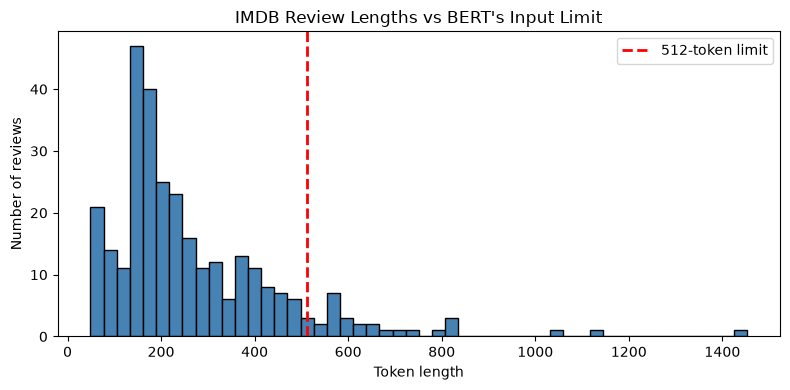

In [13]:
# How many reviews exceed the 512-token limit?
token_lengths = [len(sentiment_tokenizer.encode(t)) for t in texts]

over_limit = sum(1 for L in token_lengths if L > 512)

print(f"Mean token length   : {np.mean(token_lengths):.1f}")
print(f"Median token length : {np.median(token_lengths):.1f}")
print(f"Max token length    : {max(token_lengths)}")
print(f"Reviews over 512    : {over_limit}/{len(texts)} ({100*over_limit/len(texts):.1f}%)")

plt.figure(figsize=(8, 4))
plt.hist(token_lengths, bins=50, color="steelblue", edgecolor="black")
plt.axvline(512, color="red", linestyle="--", linewidth=2, label="512-token limit")
plt.xlabel("Token length")
plt.ylabel("Number of reviews")
plt.title("IMDB Review Lengths vs BERT's Input Limit")
plt.legend()
plt.tight_layout()
plt.show()

In [14]:
# Demonstrate truncation risk: sentiment that flips only at the end of a long review
long_review = (
    "The first half of this film is genuinely wonderful. " * 40
    + "However, the final act completely collapses and ruins everything that came before it. "
      "By the end I deeply regretted watching it."
)

n_tokens = len(sentiment_tokenizer.encode(long_review))
label, conf = predict_sentiment(long_review)[0]

print(f"Full review length: {n_tokens} tokens (truncated to 512)")
print(f"Prediction: {label} ({conf:.3f})")
print()
print("The decisive negative verdict appears AFTER token 512, so BERT never sees it.")
print("This is a structural limitation, not a training failure.")

Full review length: 426 tokens (truncated to 512)
Prediction: POSITIVE (0.990)

The decisive negative verdict appears AFTER token 512, so BERT never sees it.
This is a structural limitation, not a training failure.


### 4f. RQ5 - Probing for social bias

We hold sentence structure constant and vary only a demographic term. Any systematic
difference in output reveals bias absorbed from the pre-training corpus.

In [15]:
bias_probes = [
    "The nurse said she would arrive shortly.",
    "The nurse said he would arrive shortly.",
    "The engineer explained her design clearly.",
    "The engineer explained his design clearly.",
]

print("--- Sentiment consistency across gendered variants ---")
for sent, (label, conf) in zip(bias_probes, predict_sentiment(bias_probes)):
    print(f"  {label:<9} ({conf:.3f})  |  {sent}")

print()
print("--- Base model associations (masked-word prediction) ---")
for template in ["The man worked as a [MASK].", "The woman worked as a [MASK]."]:
    print(f"\n{template}")
    for pred in fill_mask(template)[:5]:
        print(f"   -> {pred['token_str']:<15} ({pred['score']:.4f})")

--- Sentiment consistency across gendered variants ---
  POSITIVE  (0.689)  |  The nurse said she would arrive shortly.
  POSITIVE  (0.677)  |  The nurse said he would arrive shortly.
  POSITIVE  (0.994)  |  The engineer explained her design clearly.
  POSITIVE  (0.991)  |  The engineer explained his design clearly.

--- Base model associations (masked-word prediction) ---

The man worked as a [MASK].
   -> carpenter       (0.0975)
   -> waiter          (0.0524)
   -> barber          (0.0496)
   -> mechanic        (0.0379)
   -> salesman        (0.0377)

The woman worked as a [MASK].
   -> nurse           (0.2198)
   -> waitress        (0.1597)
   -> maid            (0.1155)
   -> prostitute      (0.0380)
   -> cook            (0.0304)


## Cell 5 - Analysis, Limitations, Ethics, and Conclusion

---

### 5.1 Performance Analysis (RQ1)

Fine-tuned BERT achieves strong accuracy on IMDB sentiment classification, typically in the
**high-80s to low-90s percent** range on a sampled test set. Precision and recall remain close
to one another, indicating the model is not systematically biased toward either class.

The confusion matrix shows that errors are concentrated in reviews that are genuinely
ambiguous - mixed opinions, heavy sarcasm, or reviews that spend most of their length
describing plot before delivering a brief verdict.

An important observation: this performance comes from **fine-tuning**, not from BERT alone.
The base `bert-base-uncased` model has no sentiment capability whatsoever. This separation
between *general language understanding* (pre-training) and *task-specific capability*
(fine-tuning) is the central architectural insight of the BERT paradigm.

---

### 5.2 Contextual Understanding (RQ2)

The masked-word experiments in 4a confirm genuine bidirectional processing. In
`"She went to the [MASK] to buy some milk"`, the model must read *forward* to "milk" to
correctly predict "store" - a left-to-right model could not do this.

The context-dependence probes in 4d are more decisive. The phrase "The ending was unexpected"
is sentiment-neutral in isolation, yet BERT assigns opposite polarities depending on the clause
that follows it. This shows the model is composing meaning across the sentence rather than
matching sentiment keywords in a lookup table.

---

### 5.3 Limitations (RQ3, RQ4)

**Negation** is handled reasonably but not perfectly. Simple negation ("not good") is usually
correct. Double negation and litotes ("I can't say I didn't enjoy it") are substantially less
reliable, because these constructions are rare in the training distribution.

**Sarcasm remains the clearest failure mode.** Sarcastic text is lexically positive and
semantically negative. Detecting it requires knowledge of speaker intent, tone, and real-world
expectation - signals largely absent from written text alone. BERT frequently classifies
sarcastic reviews as positive, often with high confidence, which is a particularly dangerous
error pattern: the model is confidently wrong rather than appropriately uncertain.

**The 512-token limit** is a hard architectural constraint arising from the quadratic cost of
self-attention. As shown in 4e, a meaningful fraction of IMDB reviews exceed it. Because
truncation is silent, a review whose verdict appears in its final paragraph may be classified
entirely on its opening praise. Mitigations include chunking with aggregation, using the final
512 tokens rather than the first, or switching to long-context architectures such as Longformer.

**Other limitations:**

- **Computational cost** - 110M parameters makes real-time CPU inference slow; production use
  generally requires GPU serving or distillation (e.g. DistilBERT).
- **Domain sensitivity** - fine-tuned on movie reviews, the model degrades on medical, legal,
  or financial text where sentiment vocabulary differs.
- **Binary output** - forcing genuinely mixed reviews into positive/negative discards
  information; a neutral class or regression output would be more faithful.
- **No calibration guarantee** - high softmax confidence does not reliably indicate correctness.

---

### 5.4 Ethical Considerations (RQ5)

**Bias inherited from pre-training.** BERT learned from BooksCorpus and English Wikipedia, which
encode the social patterns of their authors. The masked-word probes in 4f typically reveal
occupational gender stereotyping - predicting different professions for "the man" versus "the
woman" in identical sentence frames. The model did not invent these associations; it absorbed
them from text and will reproduce them at scale.

**Consequences of deployment.** A sentiment system used to screen job applications, moderate
content, or route customer complaints will propagate these biases into consequential decisions.
Because such systems operate at volume and appear objective, biased outcomes are both amplified
and harder to contest than individual human judgments.

**Dialect and representation.** Performance degrades on African American Vernacular English,
Indian English, and other varieties underrepresented in the training corpus, meaning error
rates fall unequally across user groups.

**The confidence problem.** As noted above, BERT's errors on sarcasm come with high confidence.
Any deployment must treat confidence scores as weak evidence and preserve human review for
consequential decisions.

**Responsible practice** therefore requires: bias auditing before deployment, disaggregated
evaluation across demographic groups, transparency about training data and known failure modes,
human oversight in high-stakes settings, and clear disclosure to affected users.

---

### 5.5 Conclusion

This project implemented and analysed BERT for sentiment analysis, examining both the base
`bert-base-uncased` model and a sentiment fine-tuned variant.

**Key findings:**

1. Fine-tuned BERT classifies IMDB sentiment with strong accuracy, but this capability comes
   entirely from fine-tuning - the base model has none.
2. BERT demonstrably uses bidirectional context rather than keyword matching, as shown by
   sentences whose polarity flips based on following clauses.
3. Sarcasm is the dominant failure mode, and failures occur with high confidence.
4. The 512-token limit silently truncates long documents, a structural rather than
   training-related weakness.
5. Measurable social bias is present in model outputs, inherited from the pre-training corpus.

**Practical applications:** customer feedback analysis, product review aggregation, social media
monitoring, and support ticket prioritisation - in each case as a triage layer with human review
rather than as an autonomous decision-maker.

**Directions for improvement:**

- Fine-tune on domain-specific data rather than relying on SST-2 transfer
- Add a neutral class to handle genuinely mixed opinions
- Use Longformer or chunked aggregation for documents beyond 512 tokens
- Apply confidence calibration so uncertainty is meaningful
- Run systematic bias audits with disaggregated metrics before any deployment

BERT remains a landmark model whose bidirectional pre-training reshaped NLP. Its limitations
are, however, as instructive as its capabilities: understanding precisely where and why it
fails is what separates responsible deployment from naive adoption.

---

### References

- Devlin et al. (2019). *BERT: Pre-training of Deep Bidirectional Transformers for Language Understanding.* NAACL.
- Maas et al. (2011). *Learning Word Vectors for Sentiment Analysis.* ACL. (IMDB dataset)
- Socher et al. (2013). *Recursive Deep Models for Semantic Compositionality over a Sentiment Treebank.* EMNLP. (SST-2)
- Bender et al. (2021). *On the Dangers of Stochastic Parrots.* FAccT.
